In [1]:
from glob import glob

import cartopy.crs as ccrs
import numpy as np
import rasterio as rio
import rasterio.mask as rmask
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling
import ultraplot as uplt

from load_daymet_forcing_v2 import load_year_forcing, create_window_grid

%load_ext autoreload
%autoreload 2


In [2]:
print(len())

TypeError: len() takes exactly one argument (0 given)

In [2]:
dest_crs = ccrs.epsg(5070)

def prepare_for_viz(raster_file, dest_crs, mask_polygon=None):
    if mask_polygon is not None:
        orig_image, orig_transform = rmask.mask(raster_file, [mask_polygon], crop=True)
    else:
        orig_image = raster_file.read()
        orig_transform = raster_file.transform
        
    transform, width, height = calculate_default_transform(
        ccrs.PlateCarree(), dest_crs, raster_file.width, raster_file.height, *raster_file.bounds)
    
    new_image, new_transform = reproject(
        source=orig_image,
        src_transform=orig_transform,
        src_crs=ccrs.PlateCarree(),#raster_file.crs,
        dst_crs=dest_crs,
        resampling=Resampling.nearest,
        dst_nodata=np.nan)
    
    new_bounds = array_bounds(new_image.shape[1], new_image.shape[2], new_transform)
    #new_image = np.concatenate([new_image, new_image, new_image])
    new_image = new_image.transpose([1, 2, 0])
    
    # Create a nan mask
    alpha_channel = ~np.isnan(new_image[:, :, [0]])
    new_image = np.concatenate([new_image, alpha_channel], axis=2)

    return new_image, new_bounds

# arnot_forest_1_reproj, arnot_forest_1_reproj_bounds = prepare_for_viz(arnot_forest_1, dest_crs)
# arnot_forest_2_reproj, arnot_forest_2_reproj_bounds = prepare_for_viz(arnot_forest_2, dest_crs)
# arnot_forest_3_reproj, arnot_forest_3_reproj_bounds = prepare_for_viz(arnot_forest_3, dest_crs)

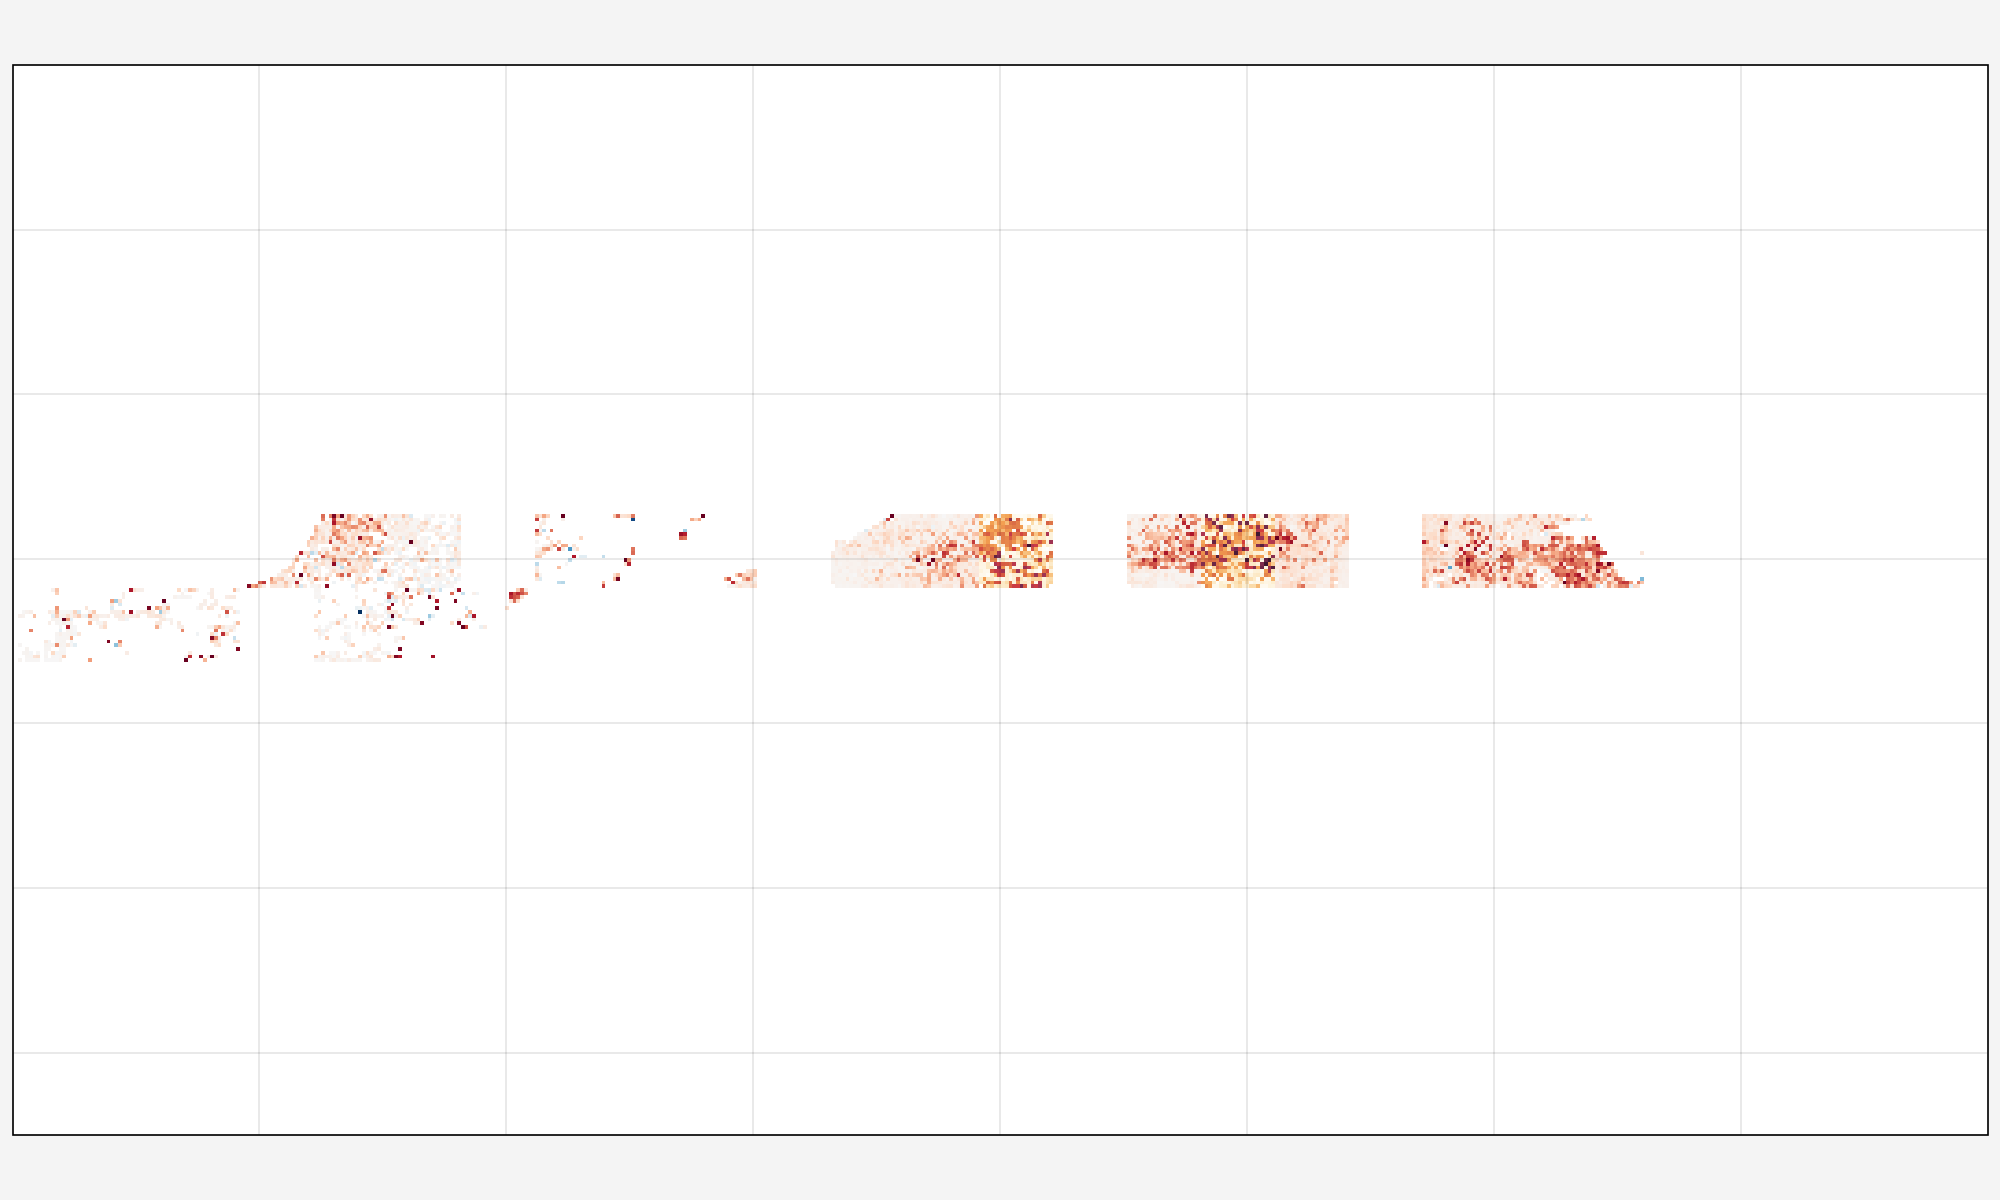

In [17]:
dest_crs = ccrs.PlateCarree()
fig, ax = uplt.subplots(proj=dest_crs, figsize=(10, 6))

for i, path in enumerate(glob("../data/924/pheno_params/pheno_params*.tif")):
    if i % 4 == 0:
        continue
    with rio.open(path) as src:
        image, bounds = prepare_for_viz(src, dest_crs)
        bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
        ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs)
ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


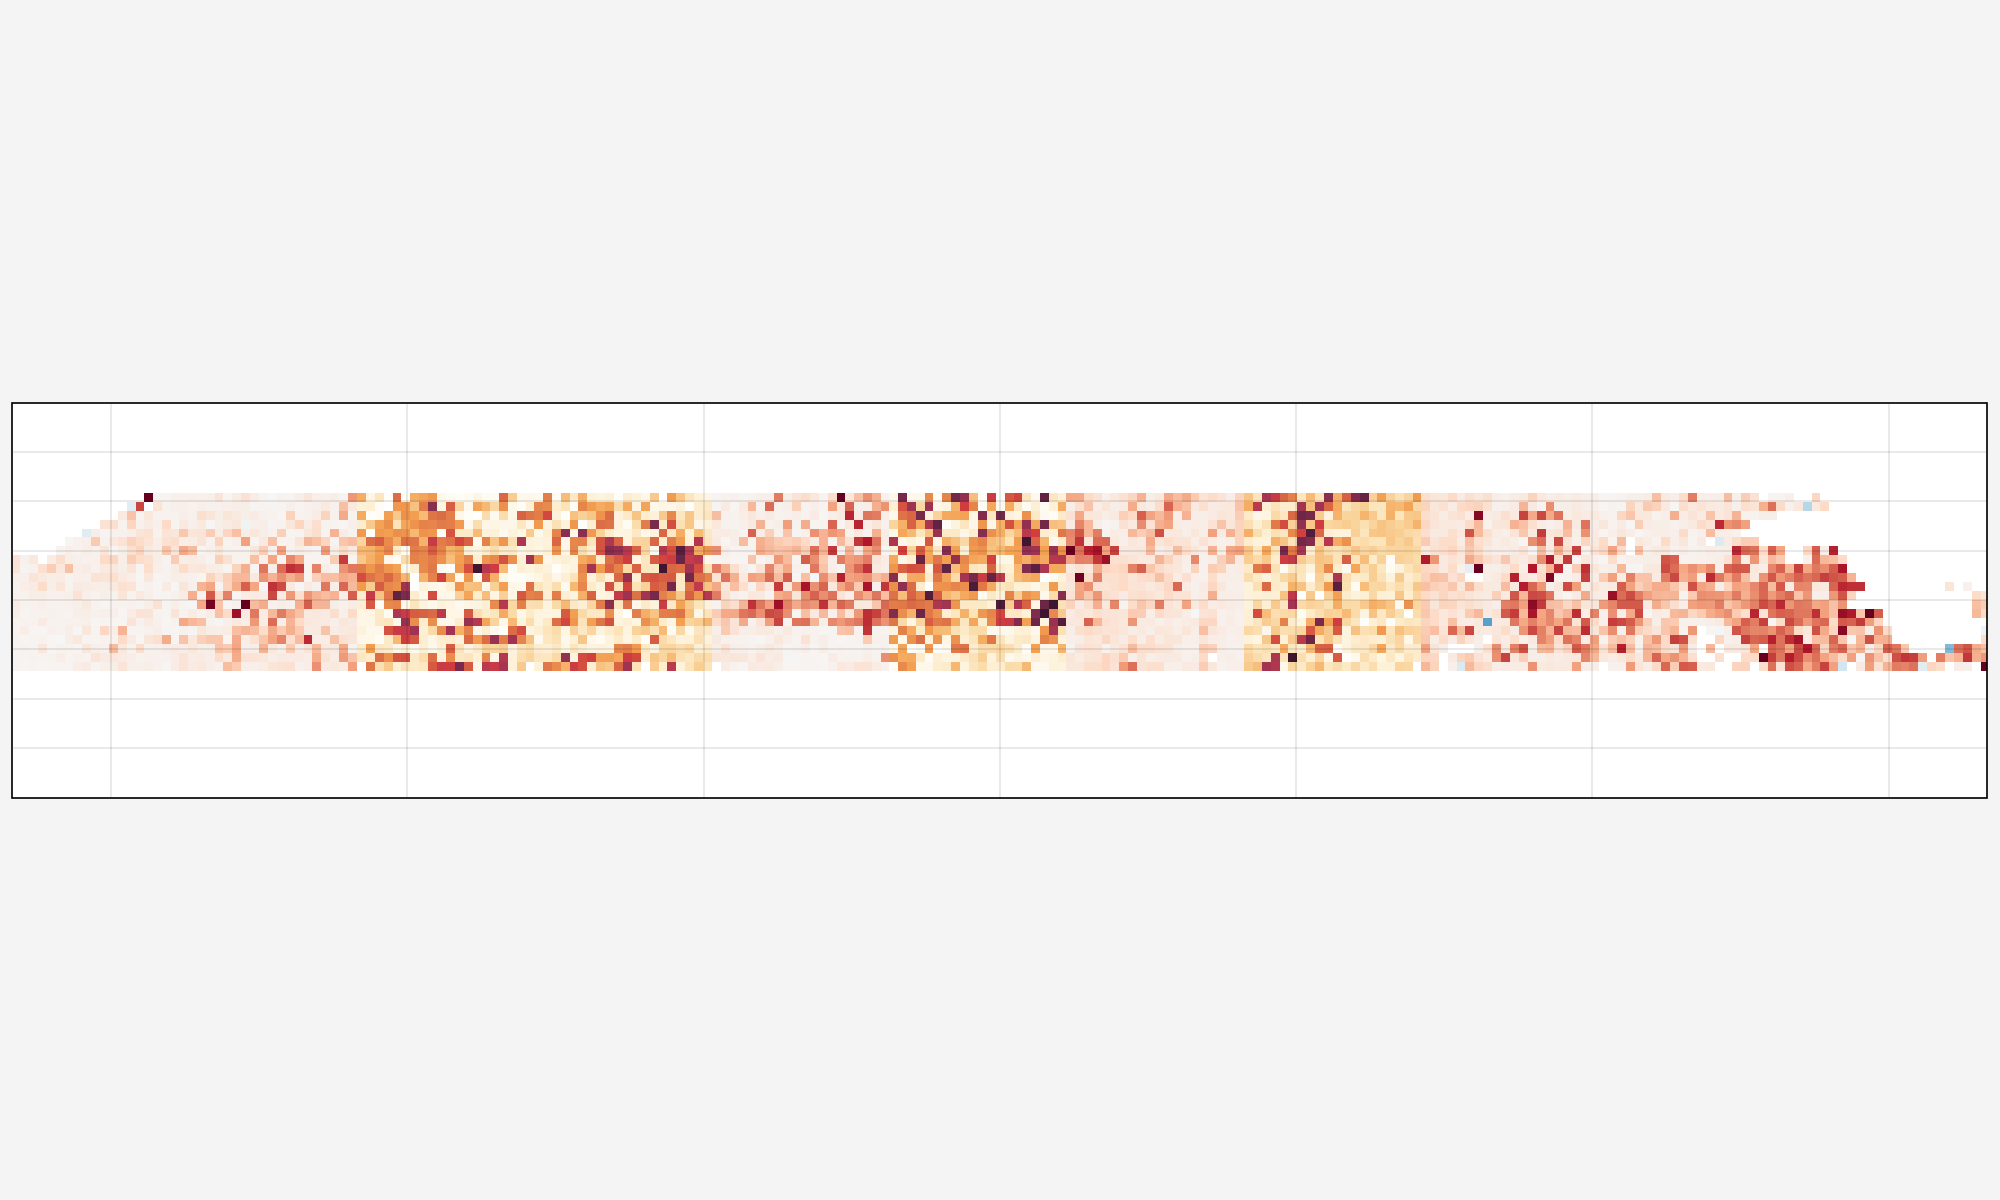

In [20]:
dest_crs = ccrs.PlateCarree()
fig, ax = uplt.subplots(proj=dest_crs, figsize=(10, 6))

for i, path in enumerate(glob("../data/924/pheno_params/pheno_params*.tif")):
    with rio.open(path) as src:
        image, bounds = prepare_for_viz(src, dest_crs)
        bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
        ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs)
ax.set_extent([-80, -70, 41, 43], crs=ccrs.PlateCarree())



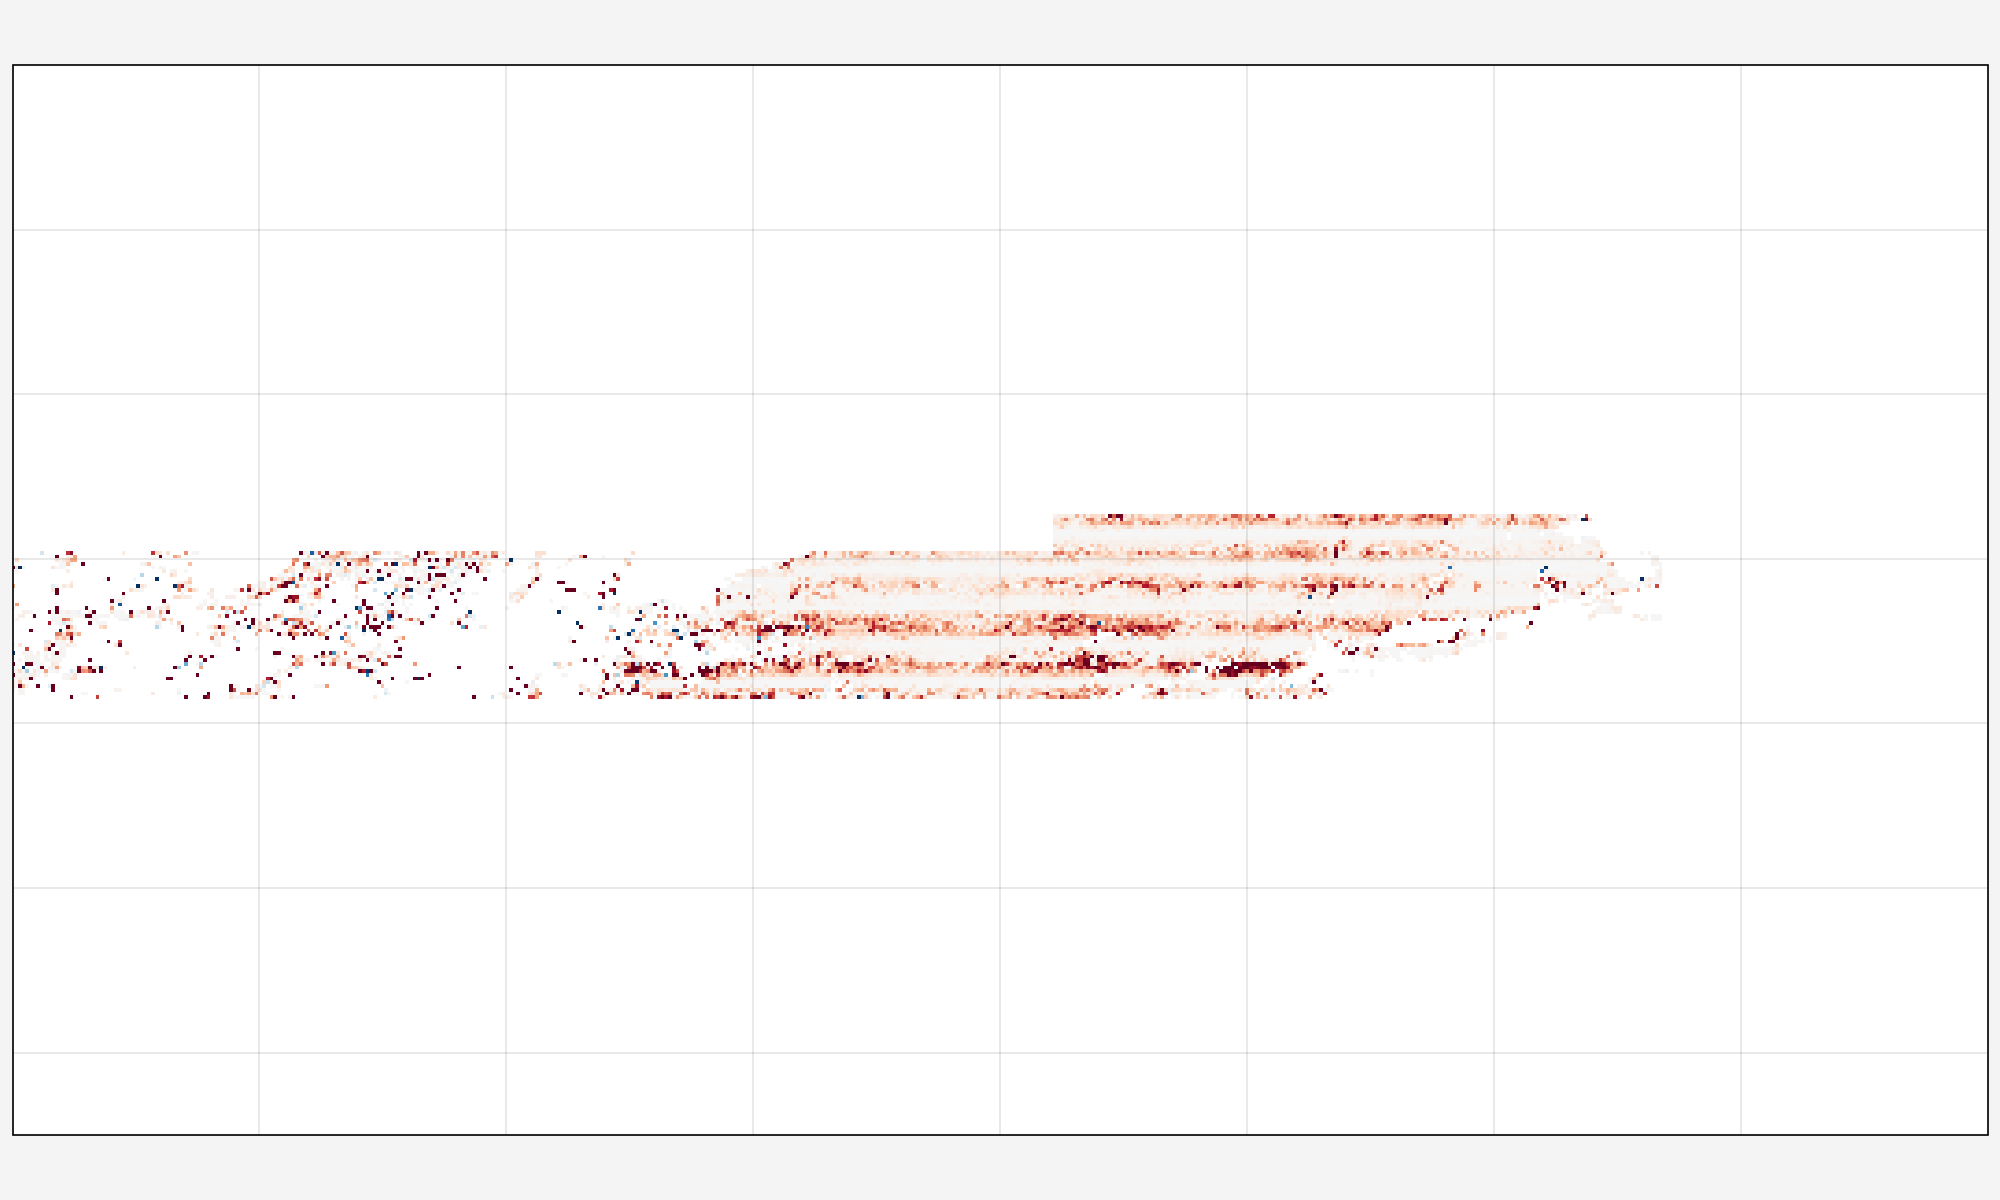

In [6]:
dest_crs = ccrs.PlateCarree()
fig, ax = uplt.subplots(proj=dest_crs, figsize=(10, 6))

for path in glob("../data/pheno_params_adamw/pheno_params_1*.tif"):
    with rio.open(path) as src:
        image, bounds = prepare_for_viz(src, dest_crs)
        bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
        ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs, vmin=-2.0, vmax=2.0)
ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


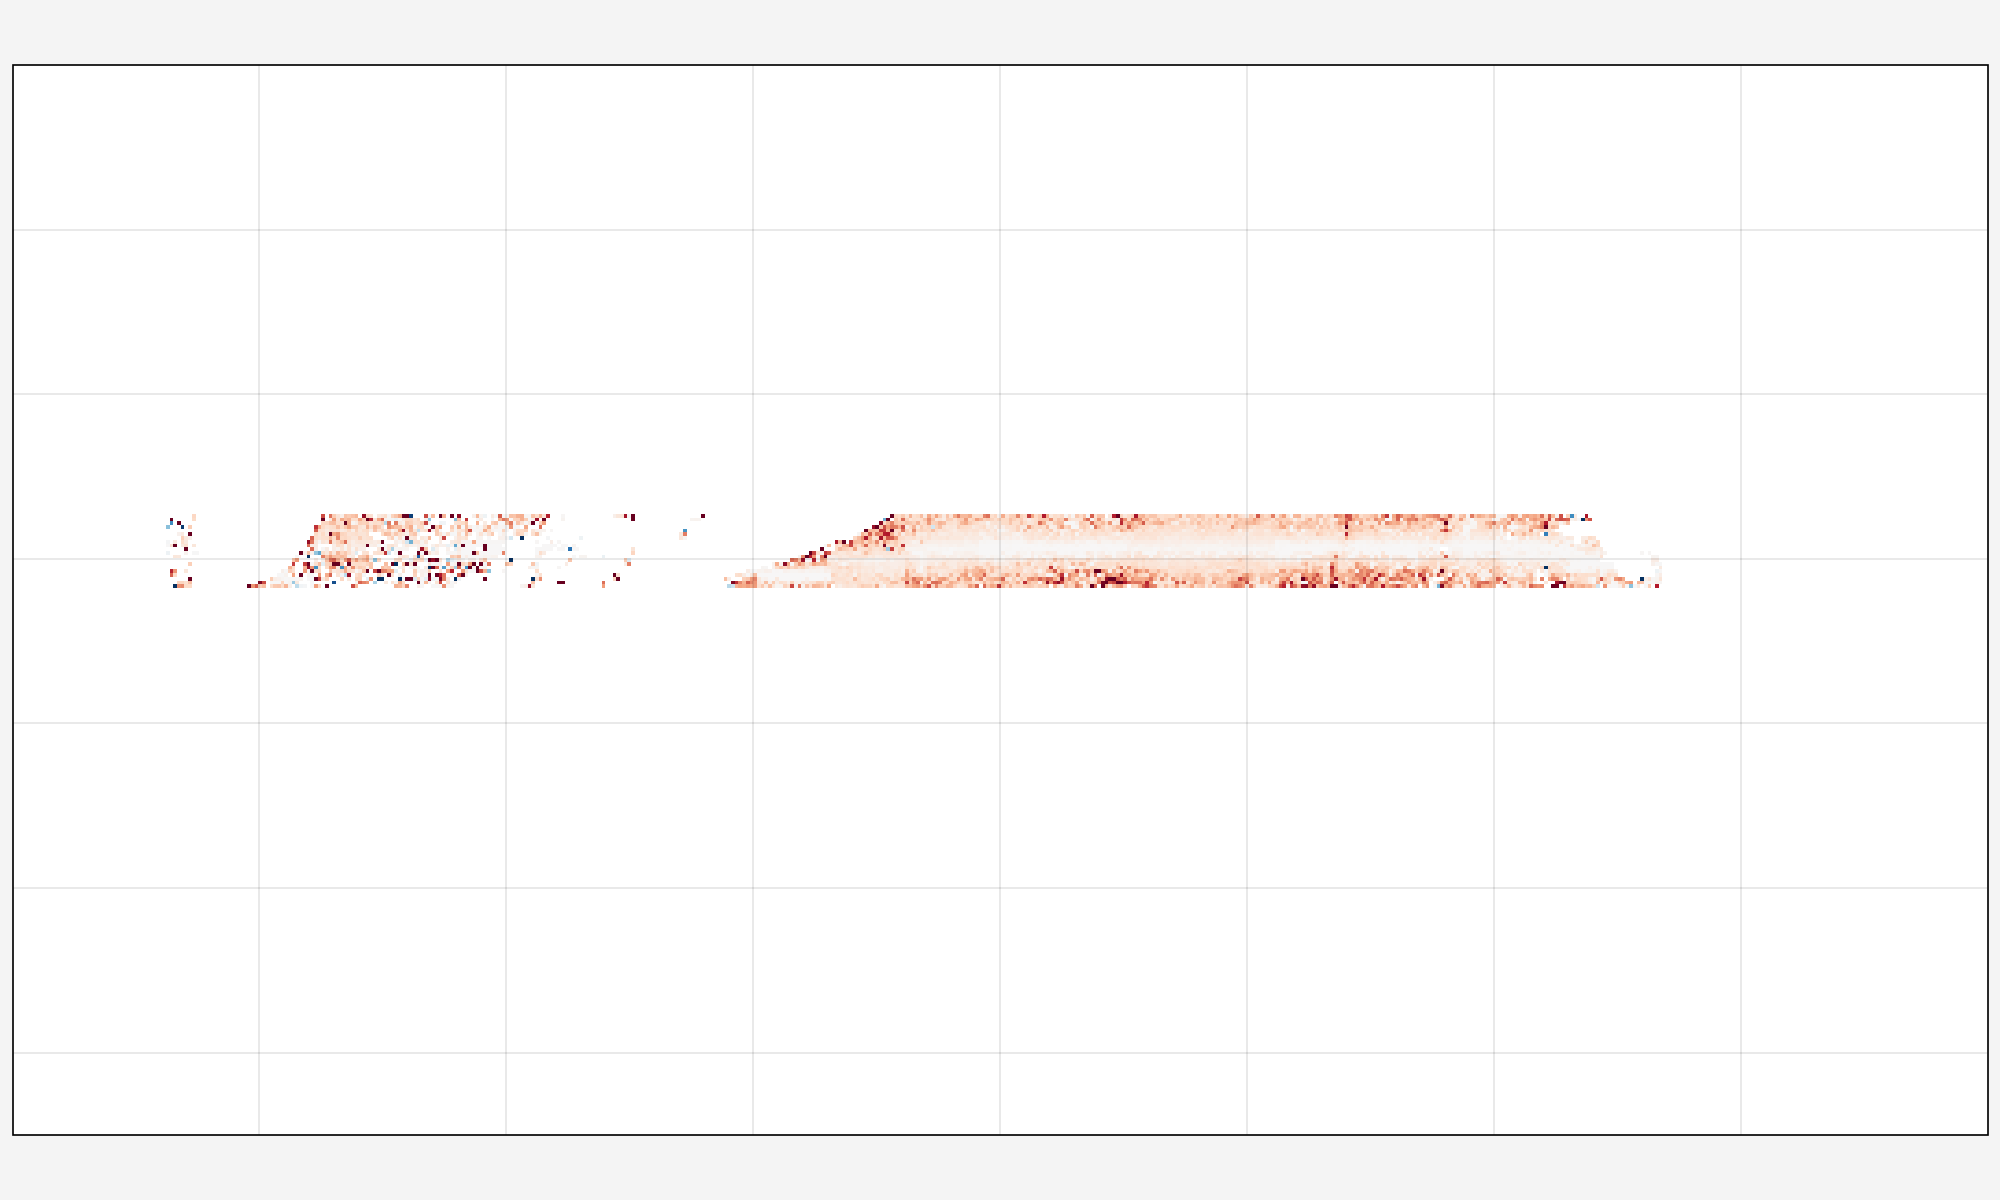

In [4]:
dest_crs = ccrs.PlateCarree()
fig, ax = uplt.subplots(proj=dest_crs, figsize=(10, 6))

for path in glob("../data/917/pheno_params/*.tif"):
    with rio.open(path) as src:
        image, bounds = prepare_for_viz(src, dest_crs)
        bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
        ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs, vmin=-2.0, vmax=2.0)
ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


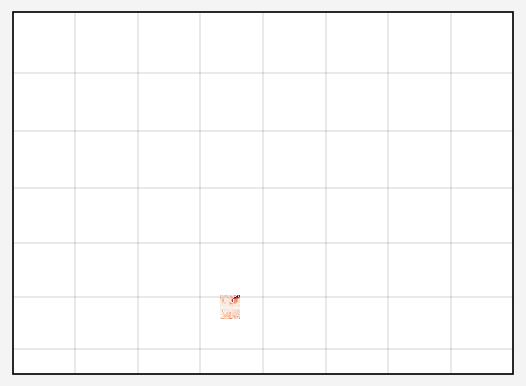

In [15]:
dest_crs = ccrs.Mercator()
fig, ax = uplt.subplots(proj=dest_crs)

paths = list(glob("../data/pheno_params/*.tif"))
with rio.open("../data/pheno_params_600.tif") as src:
    image, bounds = prepare_for_viz(src, dest_crs)
    bounds = [bounds[0], bounds[2], bounds[1], bounds[3]]
    ax.imshow(image[:,:,0], extent=bounds, transform=dest_crs)

ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


In [20]:
glob("../data/pheno_params_test/pheno_params_test/*.tif")

['../data/pheno_params_test/pheno_params_test\\pheno_params_0.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_1.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_10.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_100.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_101.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_102.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_103.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_104.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_105.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_106.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_107.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_108.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_109.tif',
 '../data/pheno_params_test/pheno_params_test\\pheno_params_11.tif',
 '../data/pheno_params_tes

../data/pheno_params\pheno_params_251.tif


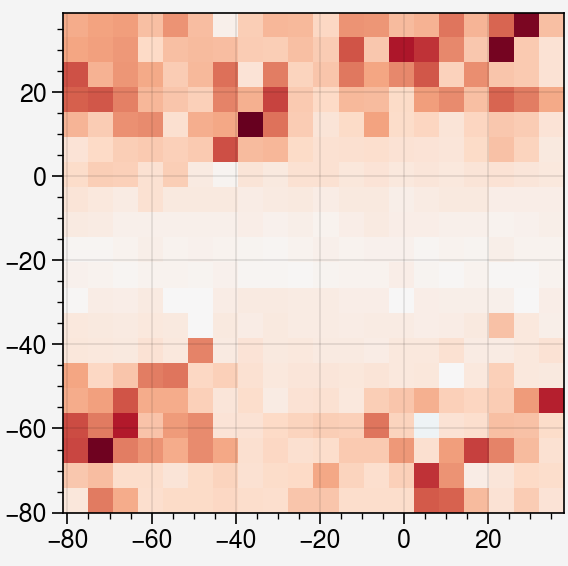

In [9]:
dest_crs = ccrs.Mercator()
fig, ax = uplt.subplots()

paths = list(glob("../data/pheno_params/*.tif"))
with rio.open(paths[400]) as src:
    test = src.read()
    print(paths[150])
    image = src.read().transpose([1, 2, 0])
    ax.imshow(image[:,:,0], extent=src.bounds)

#ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


In [64]:
test[:, 12, 12]

array([ 8.7383867e-04,  5.2278358e-02,  9.5727817e-05, -1.9938915e+01,
        7.6959944e+00], dtype=float32)

../data/pheno_params\pheno_params_1.tif
../data/pheno_params\pheno_params_10.tif
../data/pheno_params\pheno_params_100.tif
../data/pheno_params\pheno_params_1000.tif
../data/pheno_params\pheno_params_101.tif
../data/pheno_params\pheno_params_102.tif
../data/pheno_params\pheno_params_103.tif
../data/pheno_params\pheno_params_104.tif
../data/pheno_params\pheno_params_105.tif
../data/pheno_params\pheno_params_106.tif
../data/pheno_params\pheno_params_11.tif
../data/pheno_params\pheno_params_110.tif
../data/pheno_params\pheno_params_120.tif
../data/pheno_params\pheno_params_121.tif
../data/pheno_params\pheno_params_123.tif
../data/pheno_params\pheno_params_124.tif
../data/pheno_params\pheno_params_125.tif
../data/pheno_params\pheno_params_127.tif
../data/pheno_params\pheno_params_13.tif
../data/pheno_params\pheno_params_131.tif
../data/pheno_params\pheno_params_132.tif
../data/pheno_params\pheno_params_133.tif
../data/pheno_params\pheno_params_134.tif
../data/pheno_params\pheno_params_136.

AttributeError: 'CartesianAxes' object has no attribute 'set_extent'

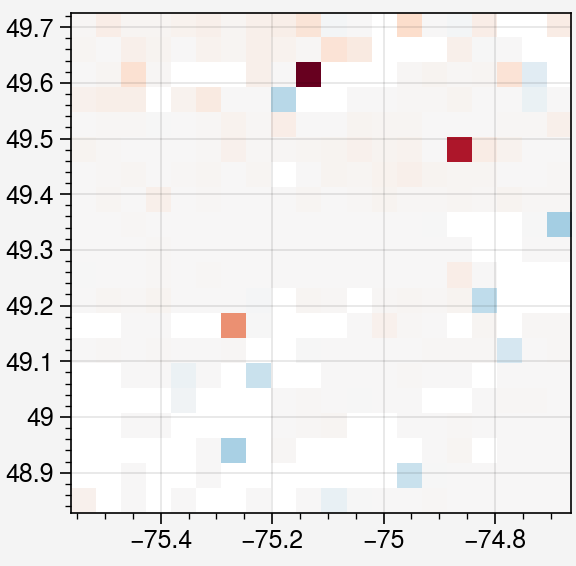

In [55]:
dest_crs = ccrs.PlateCarree()
fig, ax = uplt.subplots()

for path in glob("../data/pheno_params/*.tif"):
    with rio.open(path) as src:
        image = src.read().transpose([1, 2, 0])
        print(path)
        bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
        ax.imshow(image[:,:,0], extent=bounds)

ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


BoundingBox(left=462250.0, bottom=-526500.0, right=2948250.0, top=1241500.0)


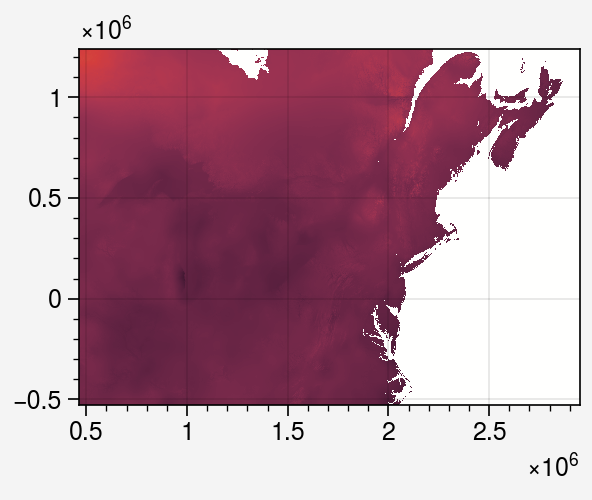

In [13]:
fig, ax = uplt.subplots()

with rio.open("../data/daymet/20091201.tif") as src:
    image = src.read().transpose([1, 2, 0])
    print(src.bounds)
    bounds = [src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]
    ax.imshow(image[:,:,1], extent=bounds)

In [50]:
# Create list of windows to loop through for model fitting.
windows = create_window_grid(
   '../data/modis/2001_01_01.tif', 200, 200)

files = load_year_forcing(2010, 
                          "../data/daymet_test",  
                          "../data/modis/2009_01_01.tif",
                          16.0,
                          windows[100])

Previous year:  0


In [26]:
files

(array([[[18.399734, 18.398369, 18.395443, 18.392448, 18.389454,
          18.386612, 18.383892, 18.381168, 18.378395, 18.375397,
          18.372406, 18.36942 , 18.366634, 18.36391 , 18.36119 ,
          18.359348, 18.359348, 18.359348, 18.359314, 18.357693],
         [18.410099, 18.408482, 18.405514, 18.402702, 18.400036,
          18.397766, 18.39518 , 18.392464, 18.389603, 18.386612,
          18.383614, 18.38065 , 18.37793 , 18.375198, 18.372475,
          18.370182, 18.368221, 18.366436, 18.36449 , 18.361858],
         [18.419636, 18.417072, 18.41349 , 18.410053, 18.406918,
          18.40458 , 18.402264, 18.399975, 18.397644, 18.395271,
          18.392868, 18.390606, 18.388493, 18.386234, 18.383762,
          18.380882, 18.378178, 18.375656, 18.373203, 18.370697],
         [18.428944, 18.425583, 18.421669, 18.41758 , 18.413933,
          18.411308, 18.408867, 18.406475, 18.404255, 18.402004,
          18.399723, 18.398071, 18.396576, 18.394932, 18.392864,
          18.390121, 1

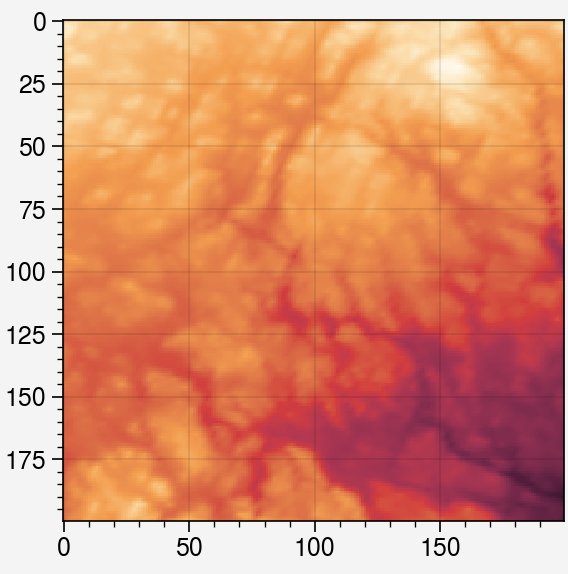

In [51]:
fig, ax = uplt.subplots()

ax.imshow(files[0].transpose([1, 2, 0]), vmin=15.2, vmax=19.0)

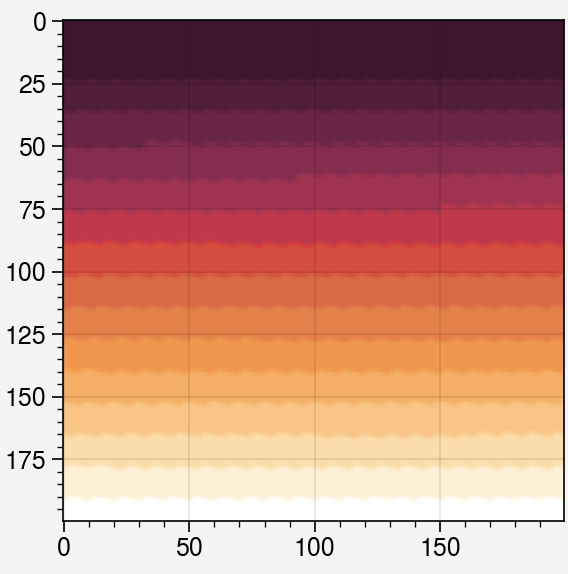

In [52]:
fig, ax = uplt.subplots()

ax.imshow(files[1].transpose([1, 2, 0]), vmin=0.604, vmax=0.607)

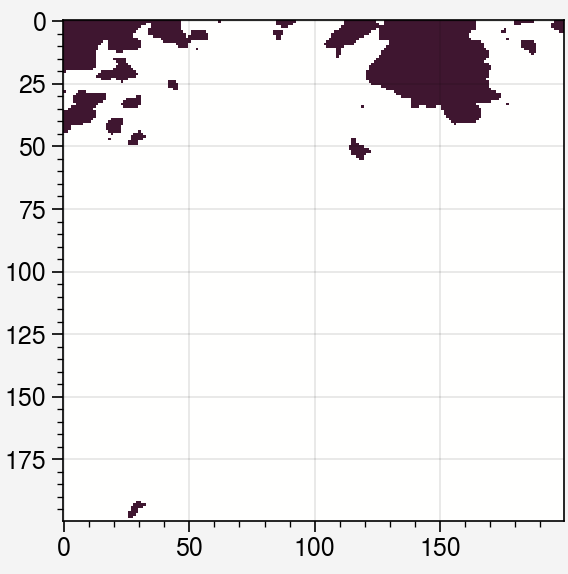

In [53]:
fig, ax = uplt.subplots()

ax.imshow(files[2].transpose([1, 2, 0]), vmin=0.0, vmax=1)

In [46]:
files[2].max()

np.float32(0.0)

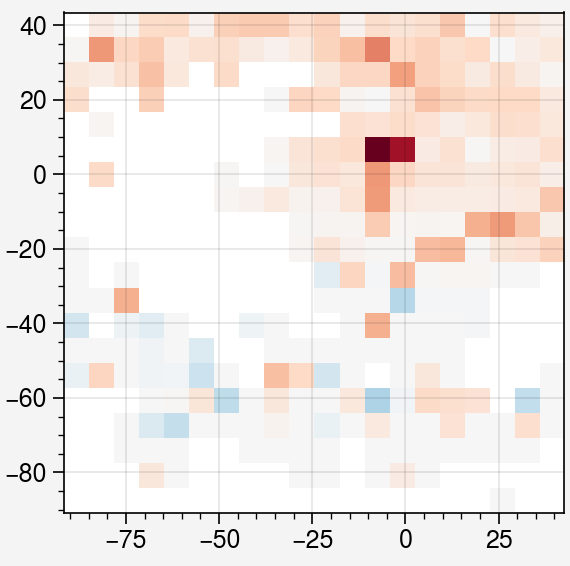

In [16]:
dest_crs = ccrs.Mercator()
fig, ax = uplt.subplots()

paths = list(glob("../data/pheno_params/pheno_params_600.tif"))
with rio.open("../data/pheno_params/pheno_params_353.tif") as src:
    test = src.read()
    image = src.read().transpose([1, 2, 0])
    ax.imshow(image[:,:,1], extent=src.bounds)

#ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())


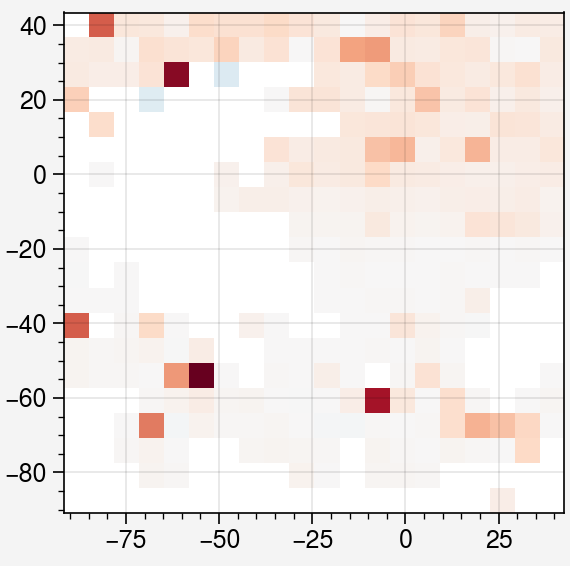

In [17]:
dest_crs = ccrs.Mercator()
fig, ax = uplt.subplots()

paths = list(glob("../data/pheno_params_261.tif"))
with rio.open("../data/pheno_params_353.tif") as src:
    test = src.read()
    image = src.read().transpose([1, 2, 0])
    ax.imshow(image[:,:,0], extent=src.bounds)

#ax.set_extent([-90, -66, 35, 48], crs=ccrs.PlateCarree())
